# Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from dotenv import load_dotenv

pd.set_option('display.max_columns',100)
pd.set_option('display.width',140)
pd.options.display.float_format = "{:,.4f}".format

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=3)

USE_ONLINE_DATA = True
load_dotenv()

print(f'Analysis window: {START_DATE.date()} to {END_DATE.date()}')
fred = Fred(os.getenv('FRED_API_KEY'))

Analysis window: 2023-06-01 to 2026-06-01


In [2]:
FRED_SERIES = {
    "DGS2" : "2Y Treasury yield",
    "DGS5" : "5Y Treasury yield",
    "DGS10" : "10Y Treasury yield",
    "DGS30" : "30Y Treasury yield",
    "BAMLC0A0CM" : "ICE BofA US Corporate OAS",
    "BAMLH0A0HYM2" : "ICE BofA US High Yield OAS",
    "VIXCLS":"CBOE VIX close",
    "T10YIE" : "10Y breakeven inflation"
}

In [3]:
ETF_TICKERS = ["AGG","LQD","HYG","TLT"]
PORTFOLIO_WEIGHTS = {
    "AGG" : 0.40,
    "LQD" : 0.25,
    "HYG" : 0.20,
    "TLT" : 0.15
}

print(f'Total weights: {sum(PORTFOLIO_WEIGHTS.values())}')

Total weights: 1.0


# Utils

In [4]:
def fetch_fred_series(series_id, start = START_DATE, end = END_DATE):
    data_series = fred.get_series(series_id)
    
    df = pd.DataFrame(data_series)
    df.columns = [series_id]
    df = df.loc[(df.index >= pd.to_datetime(start)) & (df.index <= pd.to_datetime(end))]
    return df

def fetch_fed_panel(series_dict, start, end):
    frames = []

    for series_id in series_dict:
        frames.append(fetch_fred_series(series_id,start,end))
    
    panel = pd.concat(frames, axis=1).sort_index()

    panel.index = pd.to_datetime(panel.index).tz_localize(None)

    panel = panel.asfreq("B").ffill()
    panel = panel.dropna(how='all')

    return panel

def _ar1(n, sigma, phi, rng):
    eps = rng.normal(0, sigma, n)
    out = np.zeros(n)

    for i in range(1,n):
        out[i] = phi * out[i-1] + eps[i]
    
    return out


def engineer_factor_changes(levels):

    levels = levels.copy().sort_index()
    out = pd.DataFrame(index = levels.index)


    for col in ['DGS2','DGS5','DGS10','DGS30']:
        if col in levels.columns:
            out[f'd_{col}_bp'] = levels[col].diff() * 100
    
    required_yields = ['DGS2','DGS5','DGS10','DGS30']

    if all(c in levels.columns for c in required_yields):
        levels['Rate_Level'] = levels[required_yields].mean(axis=1)
        levels['Slope_10Y_2Y'] = levels['DGS10'] - levels['DGS2']
        levels['Curvature_5Y'] = 2 * levels['DGS5'] - levels['DGS2'] - levels['DGS10']
        out['d_Rate_Level_bp'] = levels['Rate_Level'].diff() * 100
        out['d_10y2y_Slope_bp'] = levels['Slope_10Y_2Y'].diff() * 100
        out['d_Curvature_bp'] = levels['Curvature_5Y'].diff() * 100

    for col in ['BAMLC0A0CM','BAMLH0A0HYM2']:
        if col in levels.columns:
            out[f'd_{col}_bp'] = levels[col].diff() * 100
    
    if "VIXCLS" in levels.columns:
        out['d_VIX_points'] = levels['VIXCLS'].diff()
    
    if "T10YIE" in levels.columns:
        out['d_T10YIE_bp'] = levels['T10YIE'].diff() * 100


    return out.dropna(how='all')


def download_etf_prices(tickers, start, end):
    
    raw = yf.download(
        tickers,
        start = start.strftime("%Y-%m-%d"),
        end = (end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress = False,
        threads = True
    )

    if "Close" in raw.columns.get_level_values(0):
        prices = raw['Close'].copy()
    elif "Adj Close" in raw.columns.get_level_values(0):
        prices = raw['Adj Close'].copy()

    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    prices = prices.sort_index().ffill().dropna(how='all')
    
    return prices


def portfolio_returns_from_prices(prices, weights):
    rets = prices.pct_change().dropna(how='all')
    available = [ticker for ticker in weights if ticker in rets.columns]

    w = pd.Series({ticker : weights[ticker] for ticker in available},dtype=float)
    w = w/w.sum()

    port = rets[available].mul(w, axis=1).sum(axis=1).rename('Portfolio_Return')

    return port, rets[available]


In [5]:
df = fetch_fred_series('DGS2',start=START_DATE,end=END_DATE)

In [6]:
panel = fetch_fed_panel(FRED_SERIES,START_DATE,END_DATE)

In [7]:
prices = download_etf_prices(ETF_TICKERS,START_DATE,END_DATE)

<Axes: xlabel='Date'>

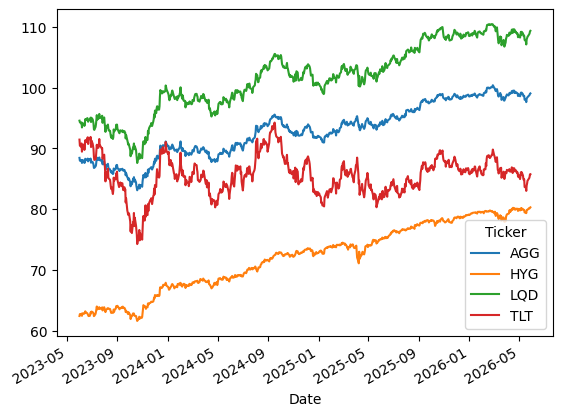

In [8]:
prices.plot()